In [ ]:
# Kmeans 

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


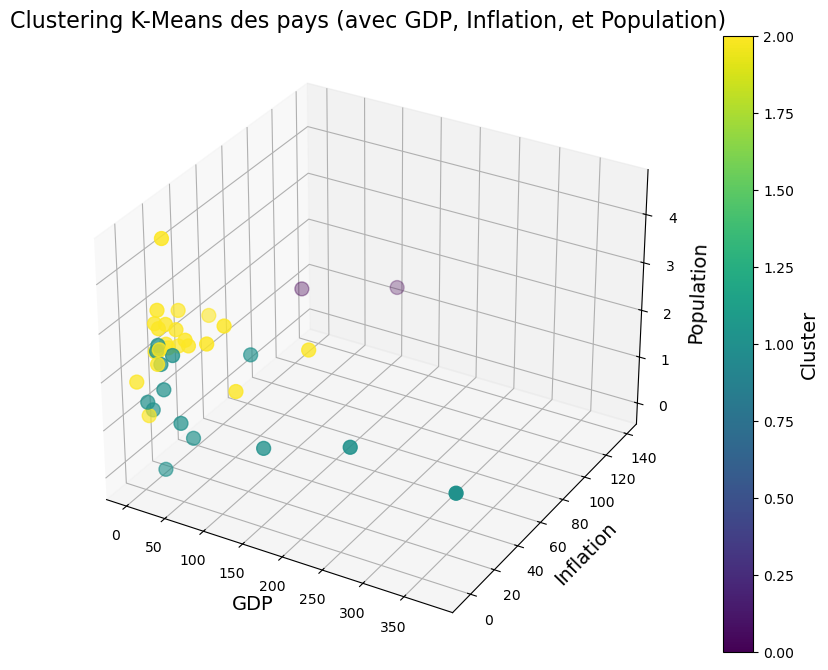

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

# Liste des pays
countries_list = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon',
    'Cape Verde', 'Central African Republic', 'Chad', 'Comoros', 'Congo',
    'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea',
    'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau',
    'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali',
    'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger',
    'Nigeria', 'Rwanda', 'São Tomé and Príncipe', 'Senegal', 'Seychelles',
    'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Togo', 'Tunisia',
    'Uganda', 'Zambia', 'Zimbabwe'
]

# Charger les fichiers CSV et Excel dans des DataFrames
gdp_df = pd.read_csv('africa_gdp_data_2000_2023.csv')  # CSV
inflation_df = pd.read_csv('Inflation_Cleaned_data.csv')  # CSV
exports_df = pd.read_csv('africa_Exports_data_with_regression.csv')  # CSV
imports_df = pd.read_csv('africa_Imports_data_with_regression.csv')  # CSV
Job_df = pd.read_excel('lab.xlsx')  # Excel
FDI_df = pd.read_excel('fdi.xlsx')  # Excel
stability_df = pd.read_excel('stb_politic.xlsx')  # Excel
urbanisation_df = pd.read_excel('urb1.xlsx')  # Excel
technology_df = pd.read_excel('techno.xlsx')  # Excel
energy_df = pd.read_excel('ene1.xlsx')  # Excel
agriculture_df = pd.read_excel('agri1.xlsx')  # Excel
population_df = pd.read_excel('grow_pop.xlsx')  # Excel

# Fonction pour uniformiser le nom de la colonne "Year"
def normalize_year_column(df):
    for col in df.columns:
        if col.lower() in ['year', 'année']:
            df.rename(columns={col: 'Year'}, inplace=True)
            break
    return df

# Normalisation des colonnes "Year" pour tous les fichiers
all_dfs = [gdp_df, inflation_df, exports_df, imports_df, Job_df, FDI_df,
           stability_df, urbanisation_df, technology_df, energy_df, agriculture_df, population_df]

all_dfs = [normalize_year_column(df) for df in all_dfs]

# Fonction pour trouver les pays communs
def find_common_countries(dataframes, countries_list):
    common_countries = set(countries_list)
    for df in dataframes:
        available_countries = set(df.columns) - {'Year'}
        common_countries &= available_countries
    return sorted(common_countries)

# Trouver les pays communs entre toutes les bases
common_countries = find_common_countries(all_dfs, countries_list)

# Fonction pour charger et préparer les données pour une année cible
def load_and_prepare_data(df, countries, target_year):
    df_filtered = df[df['Year'] == target_year]
    return df_filtered[countries].iloc[0].values

# Année cible pour l'analyse
target_year = 2023

# Créer un DataFrame combiné pour l'année cible avec toutes les bases
data_combined = {}
for name, df in zip(
    ['GDP', 'Inflation', 'Exports', 'Imports', 'Job', 'FDI', 'Stability',
     'Urbanisation', 'Technology', 'Energy', 'Agriculture', 'Population'],
    all_dfs
):
    data_combined[name] = load_and_prepare_data(df, common_countries, target_year)

# Conversion en DataFrame
data_2023 = pd.DataFrame(data_combined)

# Normalisation des données
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_2023)

# Appliquer K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

# Ajouter les labels (clusters) au DataFrame
data_2023['Cluster'] = kmeans.labels_


# Choisir trois paramètres pour la visualisation
x_param = 'GDP'
y_param = 'Inflation'
z_param = 'Population'  

# Créer un graphique 3D des clusters
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Ajouter les points dans l'espace 3D
scatter = ax.scatter(
    data_2023[x_param], data_2023[y_param], data_2023[z_param], 
    c=data_2023['Cluster'], cmap='viridis', s=100
)

# Ajouter des labels et un titre
ax.set_title(f'Clustering K-Means des pays (avec {x_param}, {y_param}, et {z_param})', fontsize=16)
ax.set_xlabel(x_param, fontsize=14)
ax.set_ylabel(y_param, fontsize=14)
ax.set_zlabel(z_param, fontsize=14)

# Ajouter la barre de couleur pour les clusters
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster', fontsize=14)

# Afficher le graphique
plt.show()

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment v

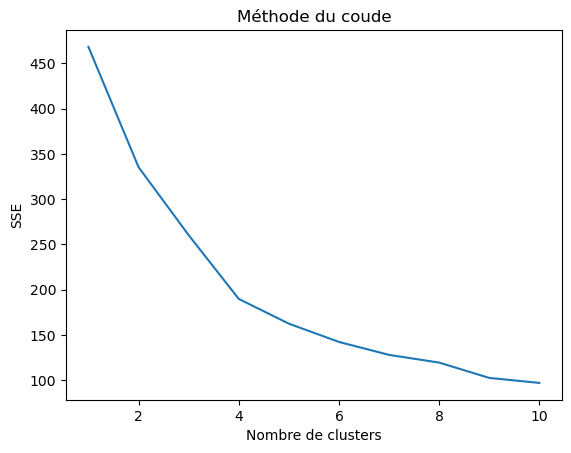

In [6]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

plt.plot(range(1, 11), sse)
plt.xlabel('Nombre de clusters')
plt.ylabel('SSE')
plt.title('Méthode du coude')
plt.show()

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


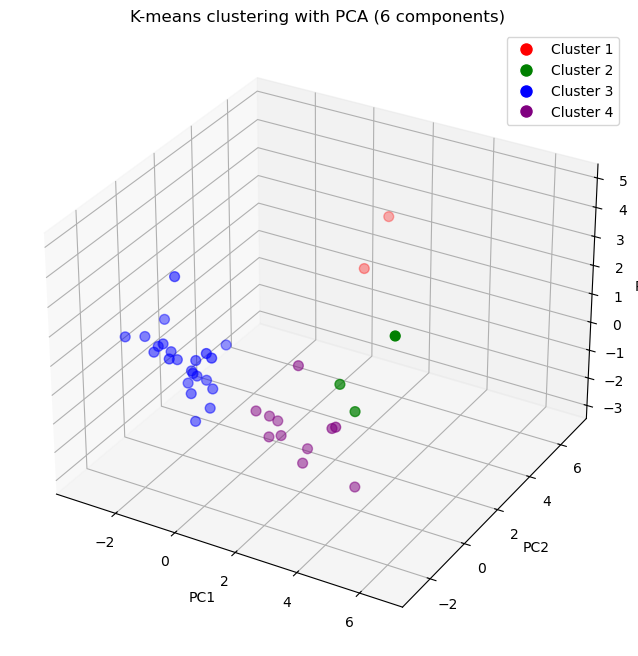

Shape of data_2023: (39, 13)
Length of labels: 39


In [35]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Suppose data_2021 is the dataframe that contains the correct number of rows
# And you are using this for scaling and clustering
# (Make sure 'data_2021' contains the 39 rows for which you are clustering)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_2023)  # Scaled data for clustering

# PCA for dimensionality reduction
pca = PCA(n_components=6)
data_reduced = pca.fit_transform(scaled_data)

# K-means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(data_reduced)

# Define colors for each cluster (update for 4 clusters)
cluster_colors = ['red', 'green', 'blue', 'purple']  

# Visualize the clustering results
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Assign colors based on the labels
point_colors = [cluster_colors[label] for label in labels]

# Scatter plot with colors corresponding to the clusters
scatter = ax.scatter(
    data_reduced[:, 0], data_reduced[:, 1], data_reduced[:, 2],
    c=point_colors, s=50
)

# Adding labels and axes titles
ax.set_title("K-means clustering with PCA (6 components)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

# Adding legend with labels for clusters (updated for 4 clusters)
ax.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label="Cluster 1"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label="Cluster 2"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label="Cluster 3"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=10, label="Cluster 4"),
    ],
    loc="best"
)

# Show the plot
plt.show()

# Verify that data_2021 and labels have the same number of rows
print(f"Shape of data_2023: {data_2023.shape}")
print(f"Length of labels: {len(labels)}")

# Add the cluster labels to data_2021
data_2023['Cluster'] = labels

# Save the results
data_2023.to_csv("resultat_clustering.csv", index=False)


C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment v

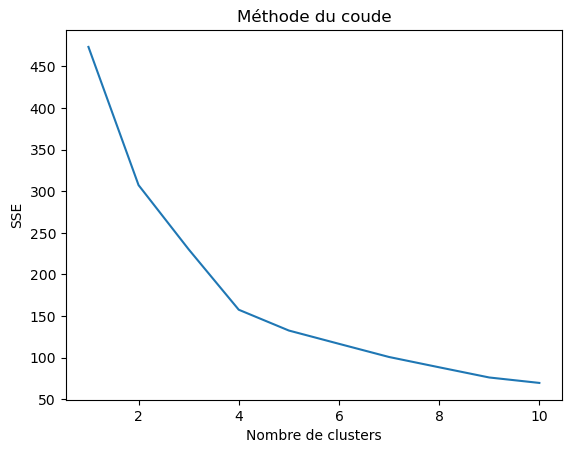

In [34]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_reduced)
    sse.append(kmeans.inertia_)

plt.plot(range(1, 11), sse)
plt.xlabel('Nombre de clusters')
plt.ylabel('SSE')
plt.title('Méthode du coude')
plt.show()

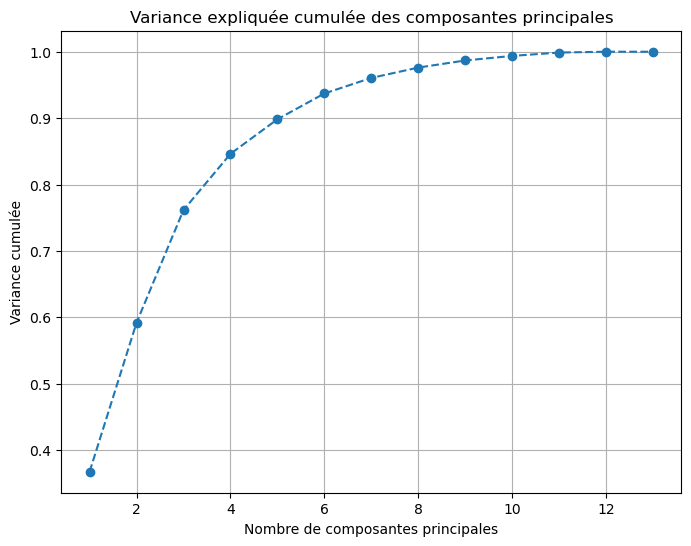

Nombre de composantes principales à garder pour 95% de la variance: 6


In [19]:
pca = PCA()  # 
pca.fit(scaled_data)

# Variance expliquée par chaque composante
explained_variance = pca.explained_variance_ratio_

# Variance cumulée
cumulative_variance = explained_variance.cumsum()

# Tracer la variance expliquée et cumulée
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Variance expliquée cumulée des composantes principales')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance cumulée')
plt.grid(True)
plt.show()

# Choisir le nombre de composantes qui expliquent 95% de la variance
n_components = next(i for i, v in enumerate(cumulative_variance) if v >= 0.95) 
print(f"Nombre de composantes principales à garder pour 95% de la variance: {n_components}")


In [ ]:
# Prediction Arima

In [ ]:
# On a essaye differenciation ordre 1 , 2 , transformation log et soustraire la moyenne mobile 
# mais les tests de ADF montrent que les series ne sont pas stationnaires 
# Cet exemple est juste pour tester Arima, on va travailler avec d=1